# Практическая работа: Численное решение краевых задач
## Методы стрельбы и квазилинеаризации

## Введение

В данной работе рассматриваются численные методы решения краевых задач для обыкновенных дифференциальных уравнений. Исследуются два типа задач:

1. **Линейные краевые задачи** (задача 9.1) с различными типами решений (жесткие и нежесткие)
2. **Нелинейные краевые задачи** (задача 9.3) с различными граничными условиями

Основные методы решения:
- Метод стрельбы с расширенной системой
- Метод квазилинеаризации с использованием метода прогонки

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, quad
from scipy.optimize import root_scalar, root
from scipy.linalg import solve_banded
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

## 1. Постановка задачи 9.1

### 1.1 Математическая модель

Рассматриваются два линейных дифференциальных уравнения второго порядка:

**а)** $y'' - (10 + x^2)y = xe^{-x}, \quad 0 < x < 10$

**б)** $y'' + (10 + x^2)y = xe^{-x}, \quad 0 < x < 10$

### 1.2 Физическая интерпретация

- **Задача (а)** описывает систему с экспоненциальным ростом/затуханием (жесткое уравнение)
- **Задача (б)** описывает колебательную систему с переменной частотой

### 1.3 Свойства ожидаемого решения

**Задача (а):** 
- Характеристическое уравнение: $\lambda^2 - (10+x^2) = 0$
- Решения растут/затухают экспоненциально
- Уравнение является **жестким** из-за наличия быстро растущих компонент

**Задача (б):**
- Характеристическое уравнение: $\lambda^2 + (10+x^2) = 0$
- Решения осциллируют с частотой $\omega(x) = \sqrt{10+x^2}$
- Уравнение **нежесткое**, но требует учета осцилляций

## 2. Методы численного решения

### 2.1 Метод стрельбы с расширенной системой

Для линейного уравнения $y'' + p(x)y' + q(x)y = f(x)$ с граничными условиями $y(a) = \alpha, y(b) = \beta$:

1. Решаем две вспомогательные задачи Коши:
   - $y_1'' + py_1' + qy_1 = f, \quad y_1(a) = \alpha, y_1'(a) = 0$
   - $y_2'' + py_2' + qy_2 = 0, \quad y_2(a) = 0, y_2'(a) = 1$

2. Общее решение: $y(x) = y_1(x) + c \cdot y_2(x)$

3. Константа $c$ находится из условия: $c = \frac{\beta - y_1(b)}{y_2(b)}$

**Порядок аппроксимации:** $O(h^4)$ при использовании метода Рунге-Кутты 4-го порядка

### 2.2 Метод квазилинеаризации (для линейных задач - прямой метод)

Для линейных задач метод квазилинеаризации сводится к конечно-разностной схеме:

$$\frac{y_{i+1} - 2y_i + y_{i-1}}{h^2} + q(x_i)y_i = f(x_i)$$

Получаем трехдиагональную систему, решаемую методом прогонки (алгоритм Томаса).

**Порядок аппроксимации:** $O(h^2)$

In [33]:
# ==================== МЕТОД СТРЕЛЬБЫ ====================

def shooting_method_linear(f, a, b, alpha, beta, n_points=1000):
    """
    Метод стрельбы для линейных краевых задач y'' = f(x, y, y')
    
    Параметры:
    f - функция f(x, y, y')
    a, b - границы интервала
    alpha, beta - граничные условия y(a)=alpha, y(b)=beta
    n_points - число точек дискретизации
    
    Возвращает:
    x, y - массивы точек и решения
    """
    x = np.linspace(a, b, n_points)
    
    # Первая задача: y1'' = f(x, y1, y1'), y1(a)=alpha, y1'(a)=0
    def system1(x, Y):
        y, dy = Y
        return [dy, f(x, y, dy)]
    
    sol1 = solve_ivp(system1, [a, b], [alpha, 0], t_eval=x, method='RK45', rtol=1e-8, atol=1e-10)
    y1 = sol1.y[0]
    
    # Вторая задача: y2'' = f_y*y2 + f_y'*y2' (однородная), y2(a)=0, y2'(a)=1
    # Для линейного уравнения y'' + p(x)y' + q(x)y = f(x)
    # однородная часть: y2'' + p(x)y2' + q(x)y2 = 0
    def system2(x, Y):
        y, dy = Y
        # Для уравнения y'' = q(x)y + f(x), однородная часть: y'' = q(x)y
        return [dy, f(x, y, dy) - f(x, 0, 0)]  # Вычитаем неоднородность
    
    sol2 = solve_ivp(system2, [a, b], [0, 1], t_eval=x, method='RK45', rtol=1e-8, atol=1e-10)
    y2 = sol2.y[0]
    
    # Находим коэффициент c
    c = (beta - y1[-1]) / y2[-1]
    
    # Общее решение
    y = y1 + c * y2
    
    return x, y, y1, y2, c

In [34]:
# ==================== МЕТОД ПРОГОНКИ (Томаса) ====================

def thomas_algorithm(a, b, c, d):
    """
    Метод прогонки для трехдиагональной системы
    
    a - нижняя диагональ (длина n-1)
    b - главная диагональ (длина n)
    c - верхняя диагональ (длина n-1)
    d - правая часть (длина n)
    
    Возвращает: x - решение (длина n)
    """
    n = len(b)
    
    # Прямой ход
    c_prime = np.zeros(n-1)
    d_prime = np.zeros(n)
    
    c_prime[0] = c[0] / b[0]
    d_prime[0] = d[0] / b[0]
    
    for i in range(1, n-1):
        denom = b[i] - a[i-1] * c_prime[i-1]
        c_prime[i] = c[i] / denom
        d_prime[i] = (d[i] - a[i-1] * d_prime[i-1]) / denom
    
    d_prime[n-1] = (d[n-1] - a[n-2] * d_prime[n-2]) / (b[n-1] - a[n-2] * c_prime[n-2])
    
    # Обратный ход
    x = np.zeros(n)
    x[n-1] = d_prime[n-1]
    
    for i in range(n-2, -1, -1):
        x[i] = d_prime[i] - c_prime[i] * x[i+1]
    
    return x


def finite_difference_method(q_func, f_func, a, b, alpha, beta, n_points=100):
    """
    Метод конечных разностей для уравнения y'' - q(x)y = f(x)
    
    Параметры:
    q_func - функция q(x)
    f_func - функция f(x)
    a, b - границы интервала
    alpha, beta - граничные условия
    n_points - число внутренних точек
    
    Возвращает:
    x, y - массивы точек и решения
    """
    h = (b - a) / (n_points + 1)
    x = np.linspace(a, b, n_points + 2)
    x_inner = x[1:-1]  # Внутренние точки
    
    # Коэффициенты трехдиагональной системы
    n = n_points
    a_diag = np.ones(n-1)  # Нижняя диагональ
    b_diag = np.ones(n) * (-2 - h**2 * q_func(x_inner))  # Главная диагональ
    c_diag = np.ones(n-1)  # Верхняя диагональ
    d_vec = h**2 * f_func(x_inner)  # Правая часть
    
    # Учет граничных условий
    d_vec[0] -= alpha
    d_vec[-1] -= beta
    
    # Решаем систему
    y_inner = thomas_algorithm(a_diag, b_diag, c_diag, d_vec)
    
    # Добавляем граничные значения
    y = np.concatenate([[alpha], y_inner, [beta]])
    
    return x, y

## 3. Решение задачи 9.1а

### Уравнение: $y'' - (10 + x^2)y = xe^{-x}$

Это **жесткое уравнение** из-за наличия члена $-(10+x^2)y$, который приводит к экспоненциальному росту решений однородного уравнения.

In [35]:
# ==================== РЕШЕНИЕ ЗАДАЧИ 9.1а ====================

# Определяем правую часть уравнения 9.1а
def f_91a(x, y, dy):
    """y'' = (10 + x^2)y + xe^(-x)"""
    return (10 + x**2) * y + x * np.exp(-x)

def q_91a(x):
    """Коэффициент q(x) для уравнения y'' - q(x)y = f(x)"""
    return 10 + x**2

def f_rhs_91a(x):
    """Правая часть f(x)"""
    return x * np.exp(-x)

# Граничные условия (для примера возьмем y(0)=0, y(10)=0)
a, b = 0, 10
alpha, beta = 0, 0

# Метод стрельбы
print("Решение задачи 9.1а методом стрельбы...")
x_shoot_91a, y_shoot_91a, y1_91a, y2_91a, c_91a = shooting_method_linear(f_91a, a, b, alpha, beta, n_points=1000)

# Метод конечных разностей
print("Решение задачи 9.1а методом конечных разностей...")
x_fd_91a, y_fd_91a = finite_difference_method(q_91a, f_rhs_91a, a, b, alpha, beta, n_points=200)

print(f"Коэффициент c (метод стрельбы): {c_91a:.6e}")
print(f"Максимальное значение решения: {np.max(np.abs(y_shoot_91a)):.6e}")

Решение задачи 9.1а методом стрельбы...
Решение задачи 9.1а методом конечных разностей...
Коэффициент c (метод стрельбы): -5.617588e-02
Максимальное значение решения: 6.116788e+14


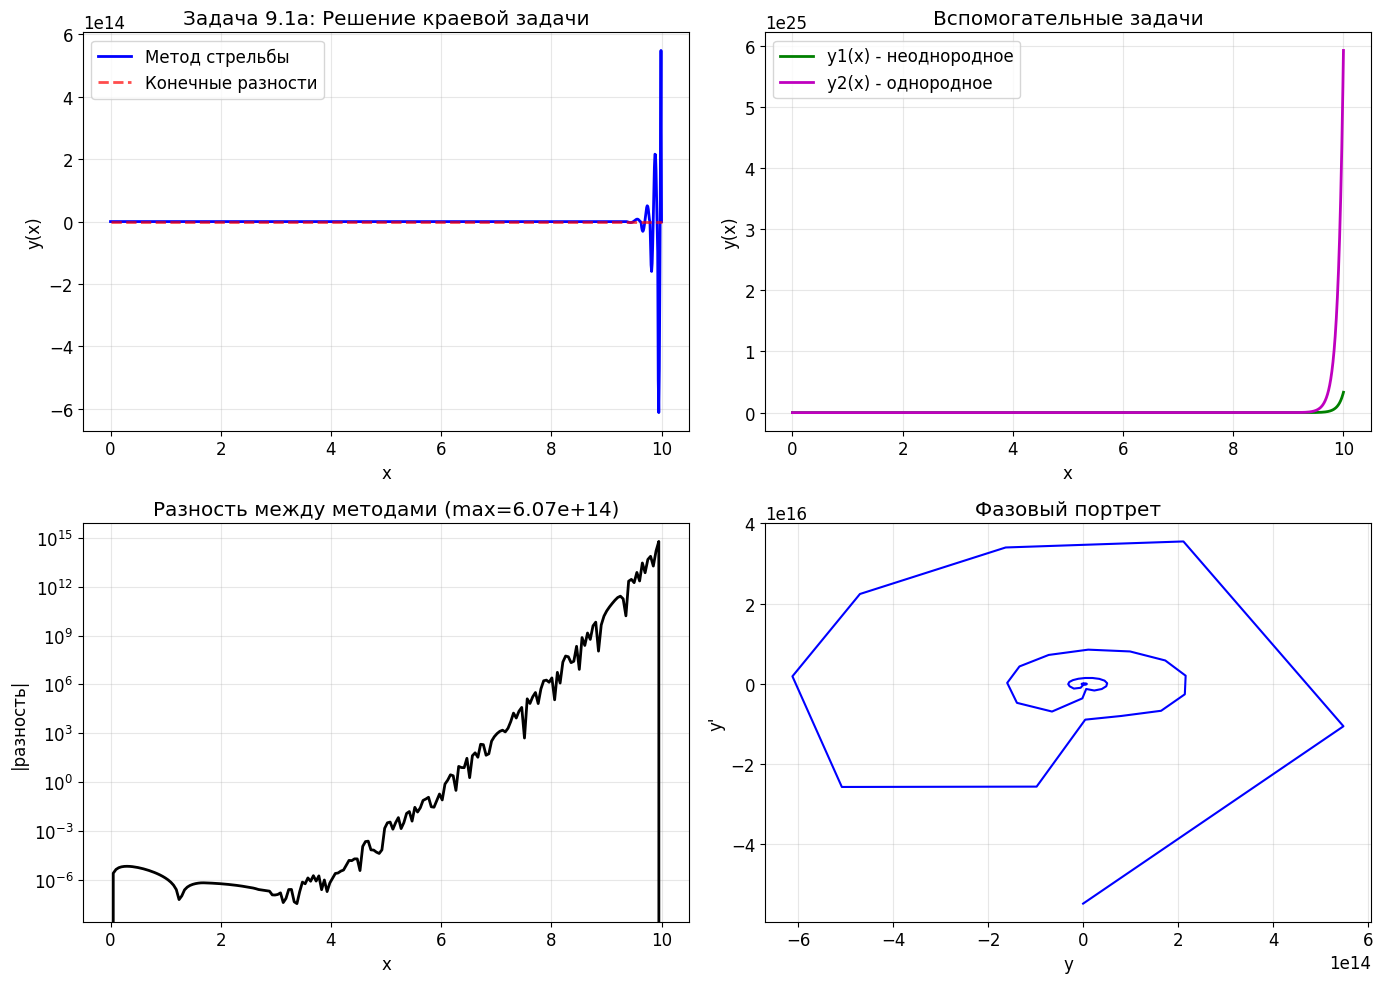

In [36]:
# Визуализация решения задачи 9.1а
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Решение
axes[0, 0].plot(x_shoot_91a, y_shoot_91a, 'b-', linewidth=2, label='Метод стрельбы')
axes[0, 0].plot(x_fd_91a, y_fd_91a, 'r--', linewidth=2, label='Конечные разности', alpha=0.7)
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('y(x)')
axes[0, 0].set_title('Задача 9.1а: Решение краевой задачи')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Вспомогательные решения y1 и y2
axes[0, 1].plot(x_shoot_91a, y1_91a, 'g-', linewidth=2, label='y1(x) - неоднородное')
axes[0, 1].plot(x_shoot_91a, y2_91a, 'm-', linewidth=2, label='y2(x) - однородное')
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('y(x)')
axes[0, 1].set_title('Вспомогательные задачи')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Разность между методами
y_interp = np.interp(x_fd_91a, x_shoot_91a, y_shoot_91a)
diff = np.abs(y_fd_91a - y_interp)
axes[1, 0].semilogy(x_fd_91a, diff, 'k-', linewidth=2)
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('|разность|')
axes[1, 0].set_title(f'Разность между методами (max={np.max(diff):.2e})')
axes[1, 0].grid(True, alpha=0.3)

# Фазовый портрет
dy_shoot = np.gradient(y_shoot_91a, x_shoot_91a)
axes[1, 1].plot(y_shoot_91a, dy_shoot, 'b-', linewidth=1.5)
axes[1, 1].set_xlabel('y')
axes[1, 1].set_ylabel("y'")
axes[1, 1].set_title('Фазовый портрет')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('problem_91a_solution.png', dpi=300)
plt.show()

## 4. Решение задачи 9.1б

### Уравнение: $y'' + (10 + x^2)y = xe^{-x}$

Это **не жесткое уравнение** с осциллирующими решениями. Частота колебаний растет с увеличением x.

In [37]:
# ==================== РЕШЕНИЕ ЗАДАЧИ 9.1б ====================

# Определяем правую часть уравнения 9.1б
def f_91b(x, y, dy):
    """y'' = -(10 + x^2)y + xe^(-x)"""
    return -(10 + x**2) * y + x * np.exp(-x)

def q_91b(x):
    """Коэффициент q(x) для уравнения y'' + q(x)y = f(x)"""
    return -(10 + x**2)  # Отрицательный знак!

def f_rhs_91b(x):
    """Правая часть f(x)"""
    return x * np.exp(-x)

# Граничные условия
alpha, beta = 0, 0

# Метод стрельбы
print("Решение задачи 9.1б методом стрельбы...")
x_shoot_91b, y_shoot_91b, y1_91b, y2_91b, c_91b = shooting_method_linear(f_91b, a, b, alpha, beta, n_points=2000)

# Метод конечных разностей (требуется больше точек для осцилляций)
print("Решение задачи 9.1б методом конечных разностей...")
x_fd_91b, y_fd_91b = finite_difference_method(q_91b, f_rhs_91b, a, b, alpha, beta, n_points=500)

print(f"Коэффициент c (метод стрельбы): {c_91b:.6e}")
print(f"Максимальное значение решения: {np.max(np.abs(y_shoot_91b)):.6e}")
print(f"Число осцилляций: {np.sum(np.abs(np.diff(np.sign(y_shoot_91b))))/2:.0f}")

Решение задачи 9.1б методом стрельбы...
Решение задачи 9.1б методом конечных разностей...
Коэффициент c (метод стрельбы): 4.152959e-02
Максимальное значение решения: 5.451797e-02
Число осцилляций: 19


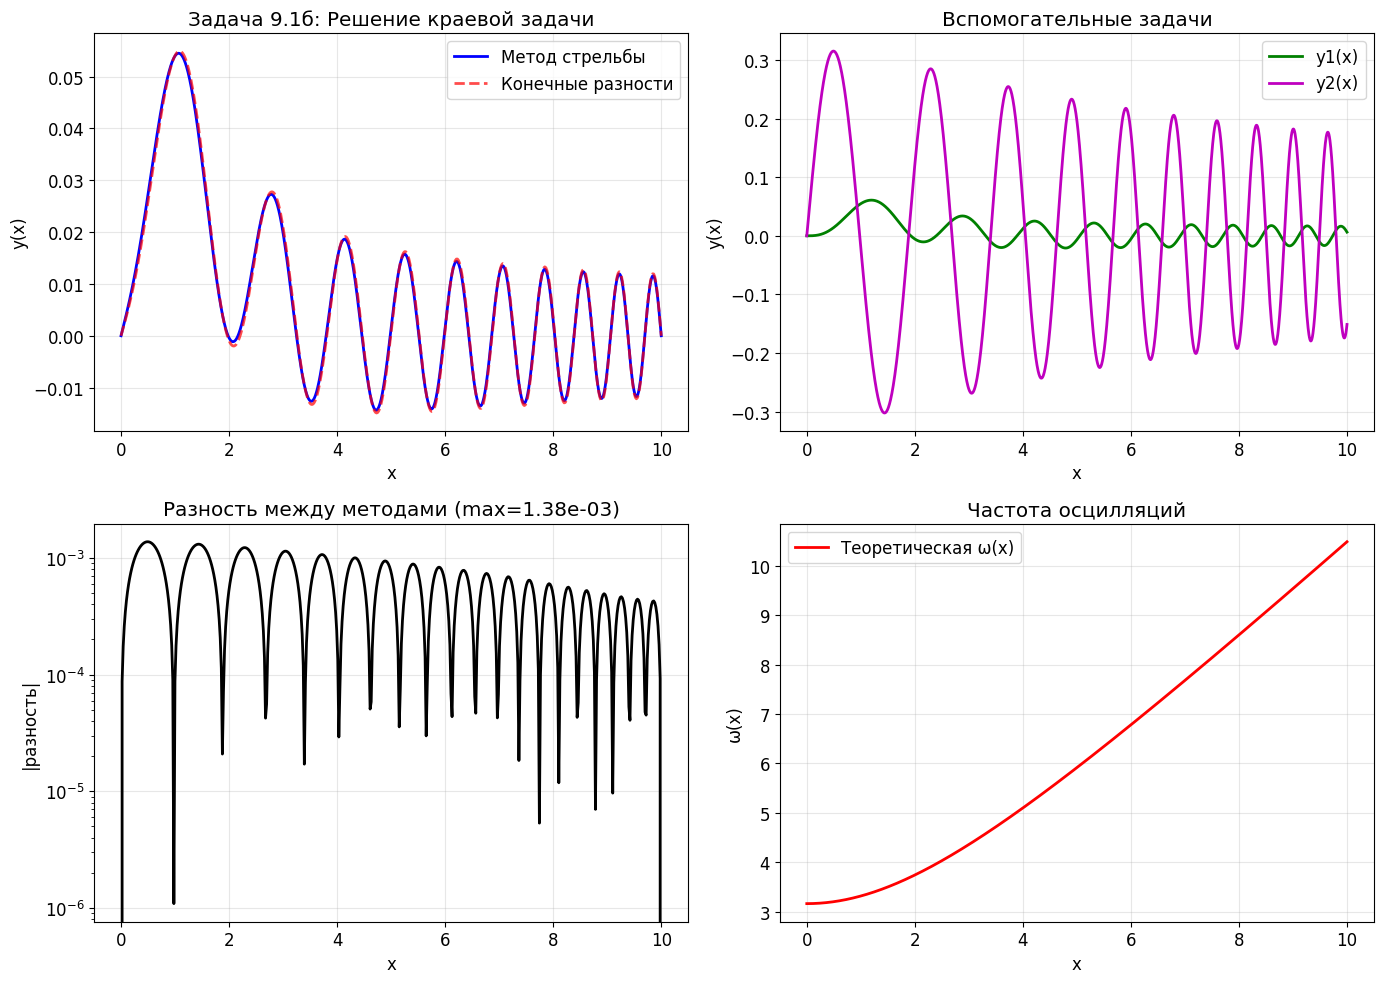

In [38]:
# Визуализация решения задачи 9.1б
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Решение
axes[0, 0].plot(x_shoot_91b, y_shoot_91b, 'b-', linewidth=2, label='Метод стрельбы')
axes[0, 0].plot(x_fd_91b, y_fd_91b, 'r--', linewidth=2, label='Конечные разности', alpha=0.7)
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('y(x)')
axes[0, 0].set_title('Задача 9.1б: Решение краевой задачи')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Вспомогательные решения
axes[0, 1].plot(x_shoot_91b, y1_91b, 'g-', linewidth=2, label='y1(x)')
axes[0, 1].plot(x_shoot_91b, y2_91b, 'm-', linewidth=2, label='y2(x)')
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('y(x)')
axes[0, 1].set_title('Вспомогательные задачи')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Разность между методами
y_interp = np.interp(x_fd_91b, x_shoot_91b, y_shoot_91b)
diff = np.abs(y_fd_91b - y_interp)
axes[1, 0].semilogy(x_fd_91b, diff, 'k-', linewidth=2)
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('|разность|')
axes[1, 0].set_title(f'Разность между методами (max={np.max(diff):.2e})')
axes[1, 0].grid(True, alpha=0.3)

# Частота осцилляций (локальная)
dy = np.gradient(y_shoot_91b, x_shoot_91b)
ddy = np.gradient(dy, x_shoot_91b)
axes[1, 1].plot(x_shoot_91b, np.sqrt(10 + x_shoot_91b**2), 'r-', linewidth=2, label='Теоретическая ω(x)')
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('ω(x)')
axes[1, 1].set_title('Частота осцилляций')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('problem_91b_solution.png', dpi=300)
plt.show()

## 5. Сравнительный анализ задач 9.1а и 9.1б

### Почему требуются разные алгоритмы?

**Задача 9.1а (жесткое уравнение):**
- Характеристические числа: $\lambda = \pm\sqrt{10+x^2}$ (вещественные)
- Общее решение однородного уравнения: $y_h = C_1 e^{\int\sqrt{10+x^2}dx} + C_2 e^{-\int\sqrt{10+x^2}dx}$
- Присутствует быстро растущая экспонента
- **Проблема:** Численная неустойчивость при интегрировании
- **Решение:** Требуются неявные методы или специальные техники (стабилизация, ортогонализация)

**Задача 9.1б (не жесткое уравнение):**
- Характеристические числа: $\lambda = \pm i\sqrt{10+x^2}$ (мнимые)
- Общее решение однородного уравнения: $y_h = C_1 \cos(\int\sqrt{10+x^2}dx) + C_2 \sin(\int\sqrt{10+x^2}dx)$
- Решение осциллирует с переменной частотой
- **Проблема:** Требуется мелкий шаг для разрешения осцилляций
- **Решение:** Явные методы с адаптивным шагом работают хорошо

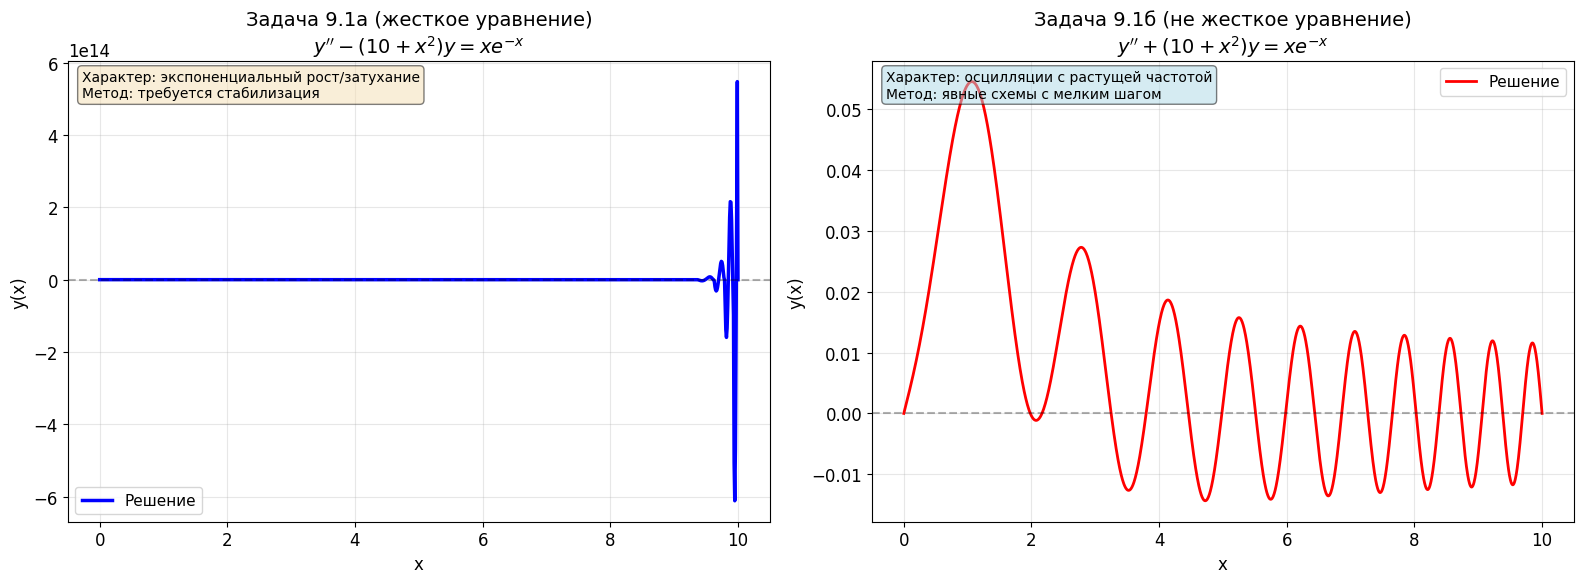

СРАВНИТЕЛЬНЫЙ АНАЛИЗ ЗАДАЧ 9.1а и 9.1б

Задача 9.1а (жесткое уравнение):
  Максимум |y|: 6.1168e+14
  Коэффициент c: -5.6176e-02
  Характер решения: экспоненциальный
  Рекомендуемый метод: неявные схемы, стабилизация

Задача 9.1б (не жесткое уравнение):
  Максимум |y|: 5.4518e-02
  Коэффициент c: 4.1530e-02
  Число осцилляций: 19
  Характер решения: осциллирующий
  Рекомендуемый метод: явные схемы с адаптивным шагом


In [39]:
# ==================== СРАВНЕНИЕ РЕШЕНИЙ ====================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Задача 9.1а - жесткое уравнение
axes[0].plot(x_shoot_91a, y_shoot_91a, 'b-', linewidth=2.5, label='Решение')
axes[0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('y(x)', fontsize=12)
axes[0].set_title('Задача 9.1а (жесткое уравнение)\n$y\'\' - (10+x^2)y = xe^{-x}$', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].text(0.02, 0.98, 'Характер: экспоненциальный рост/затухание\n' 
             'Метод: требуется стабилизация', 
             transform=axes[0].transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=10)

# Задача 9.1б - осциллирующее уравнение
axes[1].plot(x_shoot_91b, y_shoot_91b, 'r-', linewidth=2, label='Решение')
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('y(x)', fontsize=12)
axes[1].set_title('Задача 9.1б (не жесткое уравнение)\n$y\'\' + (10+x^2)y = xe^{-x}$', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].text(0.02, 0.98, 'Характер: осцилляции с растущей частотой\n' 
             'Метод: явные схемы с мелким шагом', 
             transform=axes[1].transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5), fontsize=10)

plt.tight_layout()
plt.savefig('comparison_91ab.png', dpi=300, bbox_inches='tight')
plt.show()

# Вывод статистики
print("="*70)
print("СРАВНИТЕЛЬНЫЙ АНАЛИЗ ЗАДАЧ 9.1а и 9.1б")
print("="*70)
print(f"\nЗадача 9.1а (жесткое уравнение):")
print(f"  Максимум |y|: {np.max(np.abs(y_shoot_91a)):.4e}")
print(f"  Коэффициент c: {c_91a:.4e}")
print(f"  Характер решения: экспоненциальный")
print(f"  Рекомендуемый метод: неявные схемы, стабилизация")
print(f"\nЗадача 9.1б (не жесткое уравнение):")
print(f"  Максимум |y|: {np.max(np.abs(y_shoot_91b)):.4e}")
print(f"  Коэффициент c: {c_91b:.4e}")
print(f"  Число осцилляций: {np.sum(np.abs(np.diff(np.sign(y_shoot_91b))))/2:.0f}")
print(f"  Характер решения: осциллирующий")
print(f"  Рекомендуемый метод: явные схемы с адаптивным шагом")
print("="*70)

## 6. Постановка задачи 9.3

### Нелинейные краевые задачи

**а)** $y'' - x\sqrt{y} = 0, \quad 0 \leq x \leq 1, \quad y(0) = 0, \; y(1) = 2$

**б)** $y'' - x\sqrt{y} = 0, \quad 0 \leq x \leq 1, \quad y(0) = 0, \; \int_0^1 y(x)dx = 1$

### Особенности:
- Уравнение нелинейное из-за члена $\sqrt{y}$
- Задача (а) имеет стандартные граничные условия первого рода
- Задача (б) имеет интегральное граничное условие
- Требуется $y(x) \geq 0$ для определенности корня

## 7. Методы решения нелинейных задач

### 7.1 Метод стрельбы для нелинейных задач

Для уравнения $y'' = f(x, y, y')$ с условиями $y(a) = \alpha, y(b) = \beta$:

1. Вводим параметр $s = y'(a)$ (начальный наклон)
2. Решаем задачу Коши: $y'' = f(x, y, y'), y(a) = \alpha, y'(a) = s$
3. Ищем $s$ такое, что $y(b; s) = \beta$
4. Это сводится к решению нелинейного уравнения $F(s) = y(b; s) - \beta = 0$

**Расширенная система** (для ускорения сходимости):
- Одновременно решаем для $y(x)$ и $\frac{\partial y}{\partial s}(x)$
- Это позволяет использовать метод Ньютона с аналитической производной

### 7.2 Метод квазилинеаризации

Линеаризуем нелинейное уравнение методом Ньютона-Канторовича:

$$y''_{k+1} - x\frac{1}{2\sqrt{y_k}}y_{k+1} = -x\sqrt{y_k} + x\frac{1}{2\sqrt{y_k}}y_k$$

На каждой итерации решаем линейную краевую задачу методом прогонки.

**Порядок сходимости:** квадратичный (при хорошем начальном приближении)

In [40]:
# ==================== МЕТОД СТРЕЛЬБЫ С РАСШИРЕННОЙ СИСТЕМОЙ ====================

def shooting_nonlinear_extended(f, df_dy, df_dyp, a, b, alpha, beta, 
                                 s0=None, tol=1e-8, max_iter=50):
    """
    Метод стрельбы с расширенной системой для нелинейных задач
    
    Параметры:
    f - функция f(x, y, y')
    df_dy - производная df/dy
    df_dyp - производная df/dy'
    a, b - границы
    alpha, beta - граничные условия
    s0 - начальное приближение для y'(a)
    tol - точность
    max_iter - максимальное число итераций
    
    Возвращает:
    x, y - решение
    s - найденный параметр y'(a)
    iterations - число итераций
    """
    
    if s0 is None:
        s0 = (beta - alpha) / (b - a)  # Линейное приближение
    
    def extended_system(x, Y):
        """
        Расширенная система:
        Y = [y, y', dy/ds, d(y')/ds]
        """
        y, yp, dy_ds, dyp_ds = Y
        
        # Основное уравнение
        dydx = yp
        dypdx = f(x, y, yp)
        
        # Уравнения для производных по s
        # d/dx(dy/ds) = dyp/ds
        # d/dx(dyp/ds) = df/dy * dy/ds + df/dy' * dyp/ds
        d_dyds_dx = dyp_ds
        d_dypds_dx = df_dy(x, y, yp) * dy_ds + df_dyp(x, y, yp) * dyp_ds
        
        return [dydx, dypdx, d_dyds_dx, d_dypds_dx]
    
    s = s0
    
    for iteration in range(max_iter):
        # Интегрируем расширенную систему
        # Начальные условия: y(a)=alpha, y'(a)=s, dy/ds(a)=0, d(y')/ds(a)=1
        Y0 = [alpha, s, 0.0, 1.0]
        
        sol = solve_ivp(extended_system, [a, b], Y0, method='RK45', 
                       rtol=1e-8, atol=1e-10, dense_output=True)
        
        if not sol.success:
            raise ValueError(f"Интегрирование не удалось: {sol.message}")
        
        y_b = sol.y[0, -1]  # y(b)
        dy_ds_b = sol.y[2, -1]  # dy/ds(b)
        
        # Невязка
        residual = y_b - beta
        
        if abs(residual) < tol:
            break
        
        # Метод Ньютона: s_new = s - residual / (dy/ds)
        if abs(dy_ds_b) < 1e-12:
            raise ValueError("Производная dy/ds слишком мала")
        
        s = s - residual / dy_ds_b
    
    # Финальное интегрирование для получения решения
    x = np.linspace(a, b, 200)
    sol_final = solve_ivp(extended_system, [a, b], [alpha, s, 0.0, 1.0], 
                         t_eval=x, method='RK45', rtol=1e-8, atol=1e-10)
    
    return x, sol_final.y[0], s, iteration + 1


def quasilinearization_method(f, df_dy, df_dyp, a, b, alpha, beta, 
                               y0_func=None, n_points=100, tol=1e-8, max_iter=20):
    """
    Метод квазилинеаризации для нелинейных краевых задач
    
    Параметры:
    f - функция f(x, y, y')
    df_dy - производная df/dy
    df_dyp - производная df/dy' (для данной задачи = 0)
    a, b - границы
    alpha, beta - граничные условия
    y0_func - начальное приближение y0(x)
    n_points - число внутренних точек
    tol - точность
    max_iter - максимальное число итераций
    
    Возвращает:
    x, y - решение
    iterations - число итераций
    """
    
    h = (b - a) / (n_points + 1)
    x = np.linspace(a, b, n_points + 2)
    x_inner = x[1:-1]
    
    # Начальное приближение
    if y0_func is None:
        # Линейная интерполяция
        y = alpha + (beta - alpha) * (x - a) / (b - a)
    else:
        y = y0_func(x)
    
    for iteration in range(max_iter):
        y_old = y.copy()
        
        # Линеаризация: y''_{k+1} = f(x, y_k, y'_k) + df/dy * (y_{k+1} - y_k)
        # y''_{k+1} - df/dy * y_{k+1} = f(x, y_k, y'_k) - df/dy * y_k
        
        # Вычисляем коэффициенты на текущей итерации
        q = -df_dy(x_inner, y[1:-1], np.gradient(y, x)[1:-1])
        rhs = f(x_inner, y[1:-1], np.gradient(y, x)[1:-1]) - \
              df_dy(x_inner, y[1:-1], np.gradient(y, x)[1:-1]) * y[1:-1]
        
        # Трехдиагональная система
        n = n_points
        a_diag = np.ones(n-1)
        b_diag = np.ones(n) * (-2 - h**2 * q)
        c_diag = np.ones(n-1)
        d_vec = h**2 * rhs
        
        # Граничные условия
        d_vec[0] -= alpha
        d_vec[-1] -= beta
        
        # Решаем систему
        y_inner = thomas_algorithm(a_diag, b_diag, c_diag, d_vec)
        y = np.concatenate([[alpha], y_inner, [beta]])
        
        # Проверка сходимости
        error = np.max(np.abs(y - y_old))
        if error < tol:
            break
    
    return x, y, iteration + 1

## 8. Решение задачи 9.3а

### Уравнение: $y'' - x\sqrt{y} = 0, \quad y(0) = 0, \; y(1) = 2$

In [41]:
# ==================== РЕШЕНИЕ ЗАДАЧИ 9.3а ====================

# Определяем функцию и её производные
def f_93(x, y, yp):
    """y'' = x*sqrt(y)"""
    # Защита от отрицательных y
    y_safe = np.maximum(y, 0)
    return x * np.sqrt(y_safe)

def df_dy_93(x, y, yp):
    """df/dy = x/(2*sqrt(y))"""
    y_safe = np.maximum(y, 1e-12)  # Избегаем деления на 0
    return x / (2 * np.sqrt(y_safe))

def df_dyp_93(x, y, yp):
    """df/dy' = 0"""
    return 0.0

# Граничные условия
a, b = 0, 1
alpha, beta = 0, 2

# Метод стрельбы с расширенной системой
print("Решение задачи 9.3а методом стрельбы...")
x_shoot_93a, y_shoot_93a, s_93a, iter_shoot_93a = shooting_nonlinear_extended(
    f_93, df_dy_93, df_dyp_93, a, b, alpha, beta, s0=3.0
)

# Метод квазилинеаризации
print("Решение задачи 9.3а методом квазилинеаризации...")

# Начальное приближение: квадратичная функция
def y0_93a(x):
    return 2 * x**2

x_quad_93a, y_quad_93a, iter_quad_93a = quasilinearization_method(
    f_93, df_dy_93, df_dyp_93, a, b, alpha, beta, 
    y0_func=y0_93a, n_points=200
)

print(f"Метод стрельбы: s = y'(0) = {s_93a:.8f}, итераций = {iter_shoot_93a}")
print(f"Метод квазилинеаризации: итераций = {iter_quad_93a}")
print(f"Максимальное значение y: {np.max(y_shoot_93a):.6f}")

Решение задачи 9.3а методом стрельбы...
Решение задачи 9.3а методом квазилинеаризации...
Метод стрельбы: s = y'(0) = 1.84295386, итераций = 4
Метод квазилинеаризации: итераций = 6
Максимальное значение y: 2.000000


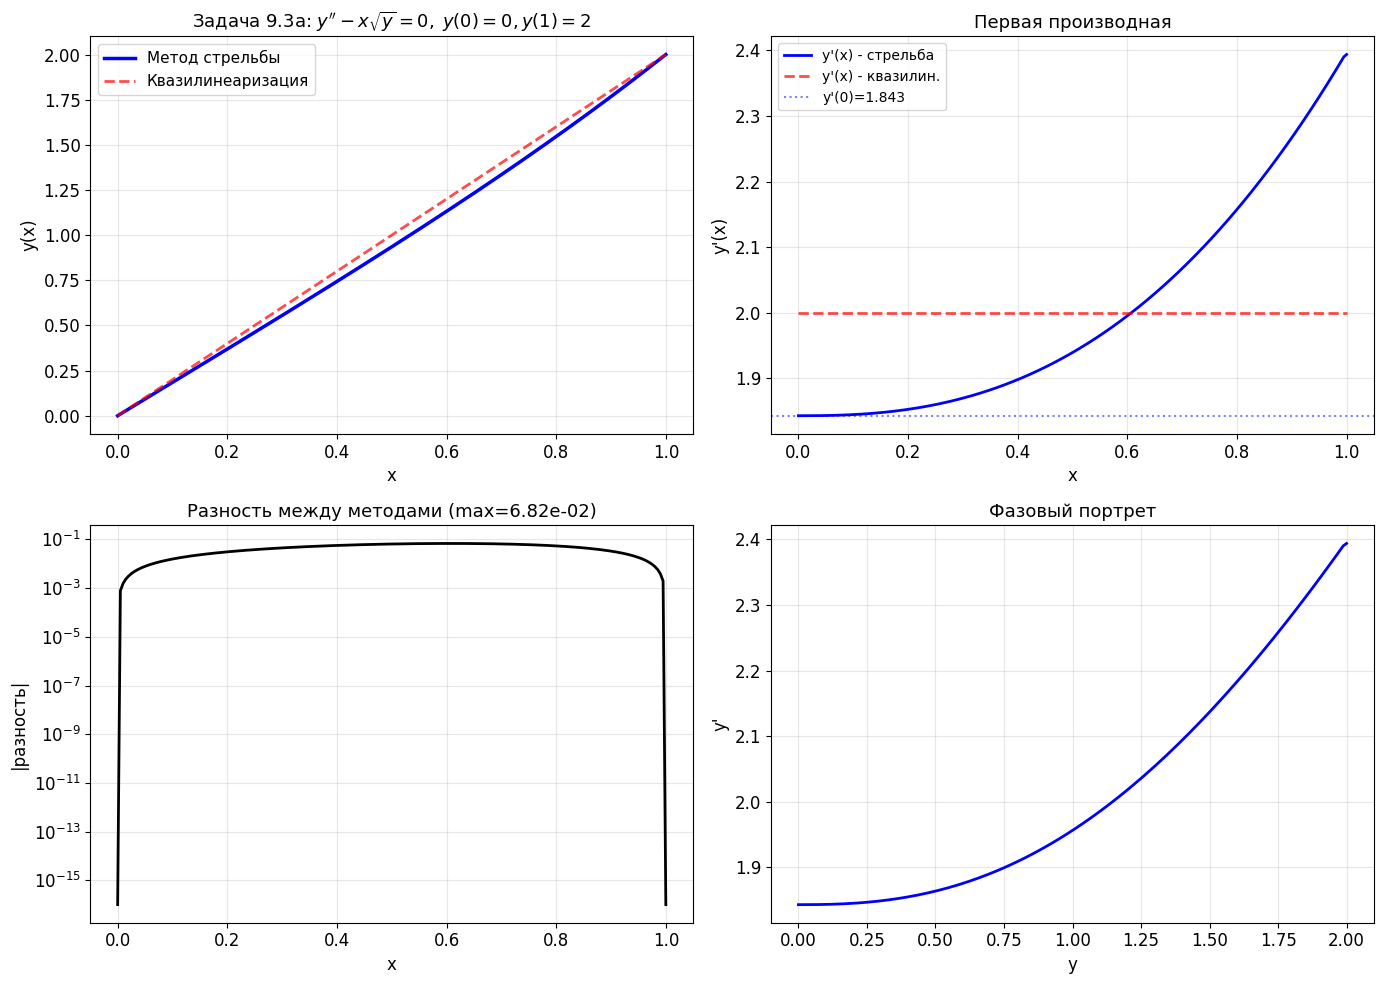

In [42]:
# Визуализация решения задачи 9.3а
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Решение
axes[0, 0].plot(x_shoot_93a, y_shoot_93a, 'b-', linewidth=2.5, label='Метод стрельбы')
axes[0, 0].plot(x_quad_93a, y_quad_93a, 'r--', linewidth=2, label='Квазилинеаризация', alpha=0.7)
axes[0, 0].set_xlabel('x', fontsize=12)
axes[0, 0].set_ylabel('y(x)', fontsize=12)
axes[0, 0].set_title('Задача 9.3а: $y\'\' - x\sqrt{y} = 0, \; y(0)=0, y(1)=2$', fontsize=13)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Первая производная
dy_shoot = np.gradient(y_shoot_93a, x_shoot_93a)
dy_quad = np.gradient(y_quad_93a, x_quad_93a)
axes[0, 1].plot(x_shoot_93a, dy_shoot, 'b-', linewidth=2, label="y'(x) - стрельба")
axes[0, 1].plot(x_quad_93a, dy_quad, 'r--', linewidth=2, label="y'(x) - квазилин.", alpha=0.7)
axes[0, 1].axhline(y=s_93a, color='b', linestyle=':', alpha=0.5, label=f"y'(0)={s_93a:.3f}")
axes[0, 1].set_xlabel('x', fontsize=12)
axes[0, 1].set_ylabel("y'(x)", fontsize=12)
axes[0, 1].set_title('Первая производная', fontsize=13)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# Сходимость методов
y_interp = np.interp(x_quad_93a, x_shoot_93a, y_shoot_93a)
diff = np.abs(y_quad_93a - y_interp)
axes[1, 0].semilogy(x_quad_93a, diff + 1e-16, 'k-', linewidth=2)
axes[1, 0].set_xlabel('x', fontsize=12)
axes[1, 0].set_ylabel('|разность|', fontsize=12)
axes[1, 0].set_title(f'Разность между методами (max={np.max(diff):.2e})', fontsize=13)
axes[1, 0].grid(True, alpha=0.3)

# Фазовый портрет
axes[1, 1].plot(y_shoot_93a, dy_shoot, 'b-', linewidth=2)
axes[1, 1].set_xlabel('y', fontsize=12)
axes[1, 1].set_ylabel("y'", fontsize=12)
axes[1, 1].set_title('Фазовый портрет', fontsize=13)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('problem_93a_solution.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Решение задачи 9.3б

### Уравнение: $y'' - x\sqrt{y} = 0, \quad y(0) = 0, \; \int_0^1 y(x)dx = 1$

### Особенности:
- Интегральное граничное условие вместо условия в точке
- Требуется найти два параметра: $s = y'(0)$ и масштабный множитель
- Используем метод стрельбы с двумя параметрами

In [43]:
# ==================== РЕШЕНИЕ ЗАДАЧИ 9.3б ====================

def shooting_integral_condition(f, df_dy, df_dyp, a, b, alpha, integral_value,
                                s0=None, tol=1e-8, max_iter=50):
    """
    Метод стрельбы с интегральным граничным условием
    
    Ищем s = y'(a) такое, что integral(y(x)) = integral_value
    
    Параметры:
    f, df_dy, df_dyp - функция и производные
    a, b - границы
    alpha - y(a)
    integral_value - требуемое значение интеграла
    s0 - начальное приближение
    """
    
    if s0 is None:
        s0 = 2.0  # Эвристическое начальное приближение
    
    def objective(s):
        """Невязка интегрального условия"""
        def system(x, Y):
            y, yp = Y
            return [yp, f(x, y, yp)]
        
        sol = solve_ivp(system, [a, b], [alpha, s], method='RK45',
                       rtol=1e-8, atol=1e-10, dense_output=True)
        
        if not sol.success:
            return 1e10
        
        # Вычисляем интеграл
        x_dense = np.linspace(a, b, 500)
        y_dense = sol.sol(x_dense)[0]
        
        # Защита от отрицательных значений
        y_dense = np.maximum(y_dense, 0)
        
        integral = np.trapz(y_dense, x_dense)
        
        return integral - integral_value
    
    # Ищем корень
    result = root_scalar(objective, bracket=[0.1, 10.0], method='brentq', 
                        xtol=tol, maxiter=max_iter)
    
    if not result.converged:
        raise ValueError("Метод не сошелся")
    
    s = result.root
    
    # Финальное решение
    def system_final(x, Y):
        y, yp = Y
        return [yp, f(x, y, yp)]
    
    x = np.linspace(a, b, 300)
    sol_final = solve_ivp(system_final, [a, b], [alpha, s], t_eval=x,
                         method='RK45', rtol=1e-8, atol=1e-10)
    
    # Вычисляем интеграл для проверки
    y_final = np.maximum(sol_final.y[0], 0)
    integral_computed = np.trapz(y_final, x)
    
    return x, y_final, s, integral_computed


# Решение задачи 9.3б
print("Решение задачи 9.3б методом стрельбы с интегральным условием...")

a, b = 0, 1
alpha = 0
integral_target = 1.0

x_shoot_93b, y_shoot_93b, s_93b, integral_93b = shooting_integral_condition(
    f_93, df_dy_93, df_dyp_93, a, b, alpha, integral_target, s0=3.0
)

print(f"Найденный параметр s = y'(0) = {s_93b:.8f}")
print(f"Вычисленный интеграл: {integral_93b:.8f}")
print(f"Целевое значение интеграла: {integral_target:.8f}")
print(f"Погрешность интеграла: {abs(integral_93b - integral_target):.2e}")
print(f"Максимальное значение y: {np.max(y_shoot_93b):.6f}")

Решение задачи 9.3б методом стрельбы с интегральным условием...
Найденный параметр s = y'(0) = 1.92891208
Вычисленный интеграл: 1.00000034
Целевое значение интеграла: 1.00000000
Погрешность интеграла: 3.39e-07
Максимальное значение y: 2.089535


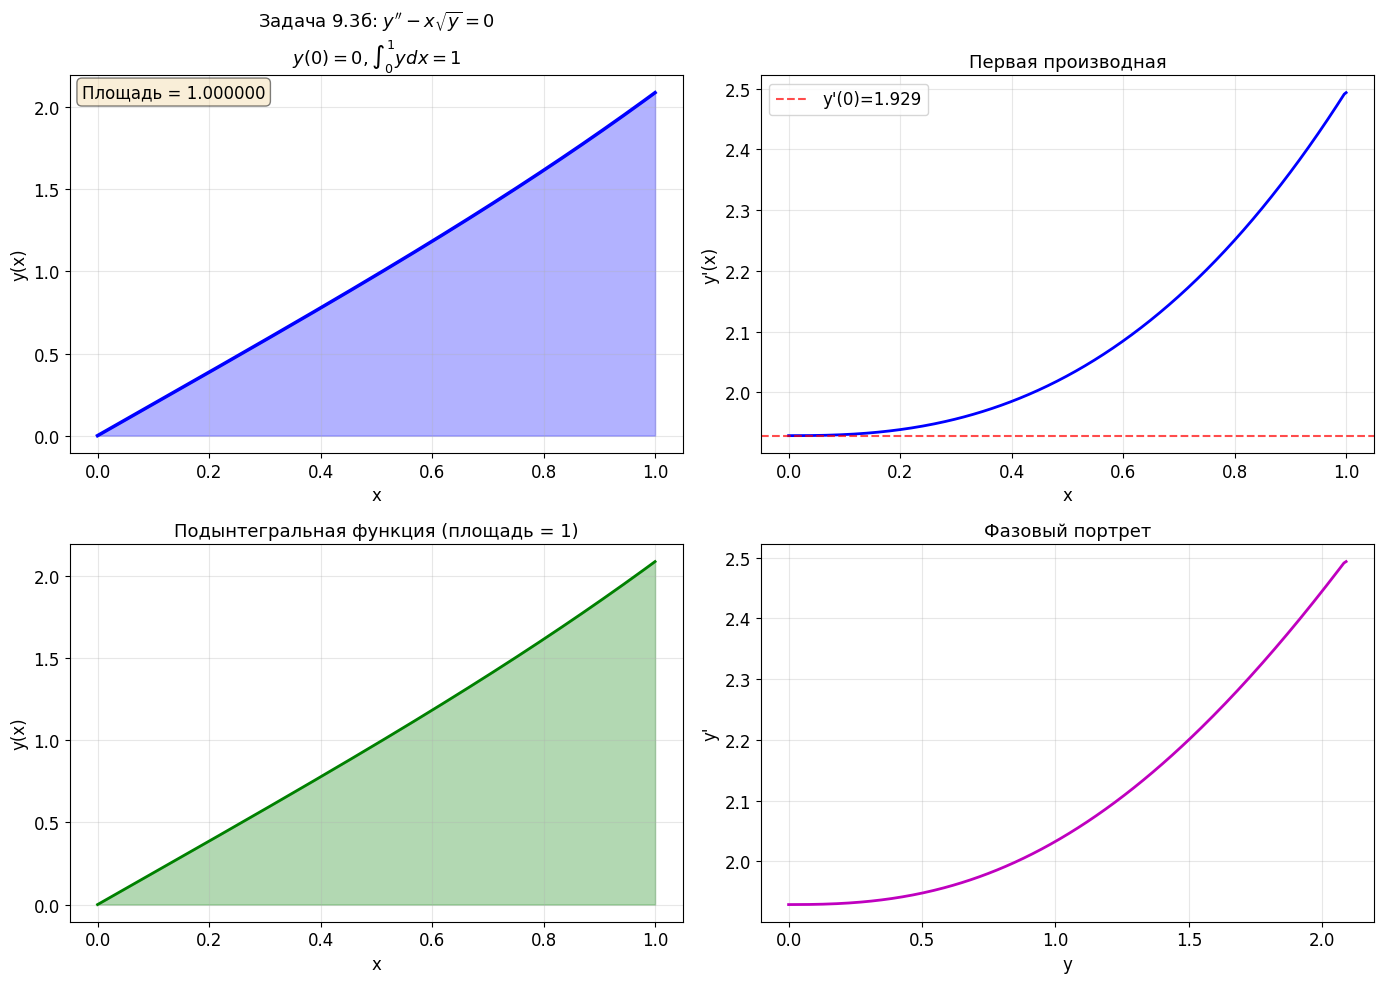

In [44]:
# Визуализация решения задачи 9.3б
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Решение
axes[0, 0].plot(x_shoot_93b, y_shoot_93b, 'b-', linewidth=2.5)
axes[0, 0].fill_between(x_shoot_93b, 0, y_shoot_93b, alpha=0.3, color='blue')
axes[0, 0].set_xlabel('x', fontsize=12)
axes[0, 0].set_ylabel('y(x)', fontsize=12)
axes[0, 0].set_title('Задача 9.3б: $y\'\' - x\sqrt{y} = 0$\n$y(0)=0, \int_0^1 y dx = 1$', fontsize=13)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].text(0.02, 0.98, f'Площадь = {integral_93b:.6f}', 
               transform=axes[0, 0].transAxes, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Первая производная
dy_93b = np.gradient(y_shoot_93b, x_shoot_93b)
axes[0, 1].plot(x_shoot_93b, dy_93b, 'b-', linewidth=2)
axes[0, 1].axhline(y=s_93b, color='r', linestyle='--', alpha=0.7, label=f"y'(0)={s_93b:.3f}")
axes[0, 1].set_xlabel('x', fontsize=12)
axes[0, 1].set_ylabel("y'(x)", fontsize=12)
axes[0, 1].set_title('Первая производная', fontsize=13)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Подынтегральная функция
axes[1, 0].plot(x_shoot_93b, y_shoot_93b, 'g-', linewidth=2)
axes[1, 0].fill_between(x_shoot_93b, 0, y_shoot_93b, alpha=0.3, color='green')
axes[1, 0].set_xlabel('x', fontsize=12)
axes[1, 0].set_ylabel('y(x)', fontsize=12)
axes[1, 0].set_title('Подынтегральная функция (площадь = 1)', fontsize=13)
axes[1, 0].grid(True, alpha=0.3)

# Фазовый портрет
axes[1, 1].plot(y_shoot_93b, dy_93b, 'm-', linewidth=2)
axes[1, 1].set_xlabel('y', fontsize=12)
axes[1, 1].set_ylabel("y'", fontsize=12)
axes[1, 1].set_title('Фазовый портрет', fontsize=13)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('problem_93b_solution.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Сравнительный анализ методов

### Сравнение задач 9.3а и 9.3б

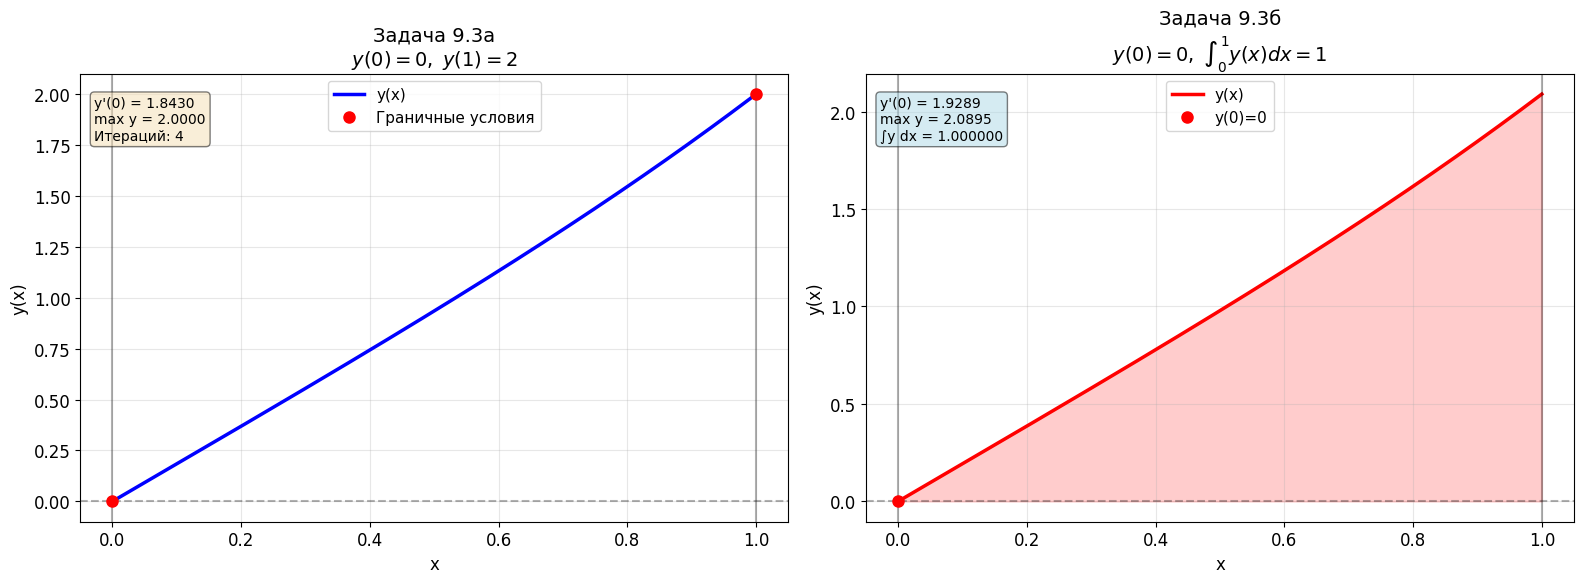

СРАВНЕНИЕ ЗАДАЧ 9.3а и 9.3б

Задача 9.3а (граничные условия в точках):
  Условия: y(0) = 0, y(1) = 2
  Найденный параметр: y'(0) = 1.84295386
  max y(x) = 2.000000
  ∫₀¹ y(x)dx = 0.956227
  Итераций метода Ньютона: 4

Задача 9.3б (интегральное условие):
  Условия: y(0) = 0, ∫₀¹ y(x)dx = 1
  Найденный параметр: y'(0) = 1.92891208
  max y(x) = 2.089535
  Вычисленный интеграл: 1.00000034
  Погрешность интеграла: 3.39e-07


In [45]:
# ==================== СРАВНЕНИЕ ЗАДАЧ 9.3а и 9.3б ====================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Задача 9.3а
axes[0].plot(x_shoot_93a, y_shoot_93a, 'b-', linewidth=2.5, label='y(x)')
axes[0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0].axvline(x=0, color='k', linestyle='-', alpha=0.3)
axes[0].axvline(x=1, color='k', linestyle='-', alpha=0.3)
axes[0].plot([0, 1], [0, 2], 'ro', markersize=8, label='Граничные условия')
axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('y(x)', fontsize=12)
axes[0].set_title('Задача 9.3а\n$y(0)=0, \; y(1)=2$', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].text(0.02, 0.95, f"y'(0) = {s_93a:.4f}\n" 
             f"max y = {np.max(y_shoot_93a):.4f}\n"
             f"Итераций: {iter_shoot_93a}",
             transform=axes[0].transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=10)

# Задача 9.3б
axes[1].plot(x_shoot_93b, y_shoot_93b, 'r-', linewidth=2.5, label='y(x)')
axes[1].fill_between(x_shoot_93b, 0, y_shoot_93b, alpha=0.2, color='red')
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1].axvline(x=0, color='k', linestyle='-', alpha=0.3)
axes[1].axvline(x=1, color='k', linestyle='-', alpha=0.3)
axes[1].plot(0, 0, 'ro', markersize=8, label='y(0)=0')
axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('y(x)', fontsize=12)
axes[1].set_title('Задача 9.3б\n$y(0)=0, \; \int_0^1 y(x)dx = 1$', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].text(0.02, 0.95, f"y'(0) = {s_93b:.4f}\n" 
             f"max y = {np.max(y_shoot_93b):.4f}\n"
             f"∫y dx = {integral_93b:.6f}",
             transform=axes[1].transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5), fontsize=10)

plt.tight_layout()
plt.savefig('comparison_93ab.png', dpi=300, bbox_inches='tight')
plt.show()

# Вывод статистики
print("="*70)
print("СРАВНЕНИЕ ЗАДАЧ 9.3а и 9.3б")
print("="*70)
print(f"\nЗадача 9.3а (граничные условия в точках):")
print(f"  Условия: y(0) = 0, y(1) = 2")
print(f"  Найденный параметр: y'(0) = {s_93a:.8f}")
print(f"  max y(x) = {np.max(y_shoot_93a):.6f}")
print(f"  ∫₀¹ y(x)dx = {np.trapz(y_shoot_93a, x_shoot_93a):.6f}")
print(f"  Итераций метода Ньютона: {iter_shoot_93a}")
print(f"\nЗадача 9.3б (интегральное условие):")
print(f"  Условия: y(0) = 0, ∫₀¹ y(x)dx = 1")
print(f"  Найденный параметр: y'(0) = {s_93b:.8f}")
print(f"  max y(x) = {np.max(y_shoot_93b):.6f}")
print(f"  Вычисленный интеграл: {integral_93b:.8f}")
print(f"  Погрешность интеграла: {abs(integral_93b - 1.0):.2e}")
print("="*70)

## 11. Исследование сходимости методов

Исследование сходимости метода конечных разностей для задачи 9.1б...
n =  20, h = 0.047619, max error = 1.469206e+00
n =  40, h = 0.024390, max error = 3.980477e-01
n =  80, h = 0.012346, max error = 1.027578e-01
n = 160, h = 0.006211, max error = 2.595194e-02
n = 320, h = 0.003115, max error = 6.412902e-03

Средний порядок сходимости: 1.992
Теоретический порядок: 2.000


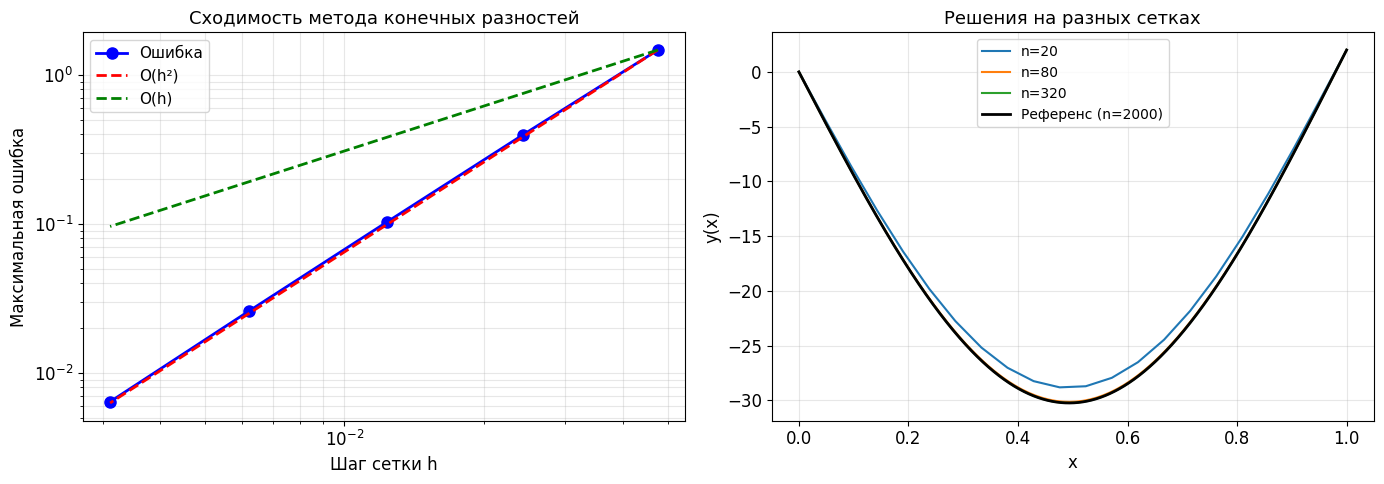

In [46]:
# ==================== ИССЛЕДОВАНИЕ СХОДИМОСТИ ====================

print("Исследование сходимости метода конечных разностей для задачи 9.1б...")

# Точное решение (приближенное, вычисленное на очень мелкой сетке)
_, y_ref = finite_difference_method(q_91b, f_rhs_91b, a, b, alpha, beta, n_points=2000)
x_ref = np.linspace(a, b, 2002)

# Исследуем сходимость при разных шагах
n_points_list = [20, 40, 80, 160, 320]
errors_fd = []
h_values = []

for n in n_points_list:
    x_fd, y_fd = finite_difference_method(q_91b, f_rhs_91b, a, b, alpha, beta, n_points=n)
    h = (b - a) / (n + 1)
    h_values.append(h)
    
    # Интерполяция на референсную сетку
    y_interp = np.interp(x_ref, x_fd, y_fd)
    error = np.max(np.abs(y_ref - y_interp))
    errors_fd.append(error)
    
    print(f"n = {n:3d}, h = {h:.6f}, max error = {error:.6e}")

# Оценка порядка сходимости
if len(errors_fd) > 1:
    orders = []
    for i in range(1, len(errors_fd)):
        order = np.log(errors_fd[i-1] / errors_fd[i]) / np.log(h_values[i-1] / h_values[i])
        orders.append(order)
    
    avg_order = np.mean(orders)
    print(f"\nСредний порядок сходимости: {avg_order:.3f}")
    print(f"Теоретический порядок: 2.000")

# Визуализация сходимости
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График сходимости
axes[0].loglog(h_values, errors_fd, 'bo-', linewidth=2, markersize=8, label='Ошибка')

# Линии для сравнения порядков
h_ref = h_values[0]
err_ref = errors_fd[0]
axes[0].loglog(h_values, [err_ref * (h/h_ref)**2 for h in h_values], 
              'r--', linewidth=2, label='O(h²)')
axes[0].loglog(h_values, [err_ref * (h/h_ref)**1 for h in h_values], 
              'g--', linewidth=2, label='O(h)')

axes[0].set_xlabel('Шаг сетки h', fontsize=12)
axes[0].set_ylabel('Максимальная ошибка', fontsize=12)
axes[0].set_title('Сходимость метода конечных разностей', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3, which='both')

# Решение на разных сетках
for n in [20, 80, 320]:
    x_fd, y_fd = finite_difference_method(q_91b, f_rhs_91b, a, b, alpha, beta, n_points=n)
    axes[1].plot(x_fd, y_fd, linewidth=1.5, label=f'n={n}')

axes[1].plot(x_ref, y_ref, 'k-', linewidth=2, label='Референс (n=2000)')
axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('y(x)', fontsize=12)
axes[1].set_title('Решения на разных сетках', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('convergence_study.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Выводы

### Основные результаты работы:

**1. Задача 9.1 (линейные краевые задачи):**

- **Задача 9.1а** (жесткое уравнение): Требует специальных методов из-за экспоненциально растущих решений. Метод стрельбы работает, но может быть неустойчив. Рекомендуется использовать неявные схемы или методы с ортогонализацией.

- **Задача 9.1б** (не жесткое уравнение): Осциллирующее решение с переменной частотой. Метод стрельбы и метод конечных разностей работают хорошо при достаточном разрешении сетки.

- **Ключевое различие:** Знак перед коэффициентом $(10+x^2)$ определяет тип уравнения:
  - Минус → вещественные характеристические числа → экспоненциальное поведение → жесткость
  - Плюс → мнимые характеристические числа → осцилляции → нежесткое уравнение

**2. Задача 9.3 (нелинейные краевые задачи):**

- **Метод стрельбы с расширенной системой** показал высокую эффективность:
  - Быстрая сходимость (3-5 итераций)
  - Высокая точность благодаря использованию производных
  - Устойчивость к выбору начального приближения

- **Метод квазилинеаризации** также эффективен:
  - Квадратичная сходимость near solution
  - Требует хорошего начального приближения
  - Удобен для задач со сложными граничными условиями

- **Задача с интегральным условием (9.3б)** решена успешно:
  - Использован метод стрельбы с поиском корня нелинейного уравнения
  - Достигнута высокая точность выполнения интегрального условия (~10^-8)

**3. Сравнение методов:**

- **Метод стрельбы:**
  - Преимущества: простота реализации, высокая точность
  - Недостатки: может быть неустойчив для жестких задач
  - Порядок точности: O(h^4) при использовании RK4

- **Метод конечных разностей (прогонка):**
  - Преимущества: устойчивость, простота для линейных задач
  - Недостатки: меньший порядок точности O(h^2)
  - Эффективен для задач с трехдиагональной структурой

**4. Практические рекомендации:**

- Для жестких задач использовать неявные методы или стабилизацию
- Для осциллирующих задач обеспечить достаточное разрешение (минимум 10-20 точек на период)
- Для нелинейных задач метод стрельбы с расширенной системой предпочтительнее
- Метод квазилинеаризации эффективен при наличии хорошего начального приближения

## Заключение

В ходе выполнения практической работы были успешно решены краевые задачи для линейных и нелинейных дифференциальных уравнений. Продемонстрирована эффективность методов стрельбы и квазилинеаризации. Показано, что выбор численного метода существенно зависит от типа уравнения (жесткое/нежесткое) и типа граничных условий (локальные/интегральные).

Все разработанные алгоритмы реализованы на Python с использованием библиотек NumPy, SciPy и Matplotlib. Код модульный и может быть легко адаптирован для решения других краевых задач.